# Homework 05: Binary Classification with Logistic Regression

#### Due Date: Sunday, October 4th at 11:59pm (with 2 hour plus 1 minute grace period)

#### The late policy is described in the DX 603 Syllabus.

### Introduction

In the previous homework, we used regression to predict a continuous numerical value. In this homework, we turn to **binary classification**, where the goal is to predict which of two classes an observation belongs to.

We will use the **UCI Spambase** dataset to build a logistic regression model that predicts whether an email is **spam** or **not spam**. This provides a useful setting for exploring an important feature of classification: a model produces probabilities, but the decision about how to convert those probabilities into class labels depends on the needs of the application.

In this homework, you will:

- Create a stratified **80% / 10% / 10% Train / Validation / Test** split.
- Establish a **majority-class baseline** for comparison.
- Train a `StandardScaler + LogisticRegression` pipeline.
- Evaluate classification performance using **accuracy, TPR, FPR, and ROC AUC**.
- Examine how changing the **decision threshold** changes the tradeoff between identifying spam and incorrectly flagging legitimate email.
- Use the validation set to choose the **highest threshold that achieves a TPR of at least 0.95**.
- Refit the final model using the complete development set and evaluate it once on the untouched test set.

This workflow reinforces an important principle from our previous work: **training data are used to fit the model, validation data are used to make modeling decisions, and test data are reserved for the final estimate of performance on previously unseen data.**

> You are **not expected to write every scikit-learn pipeline from scratch**. Reuse and adapt code from the Week 5 Coding Notebook, and use AI to help you generate or modify code when appropriate. You are responsible for **understanding** the code, running the code, checking that it follows the instructions, and interpreting the results.

### Grading

- All homeworks in DX 603 are worth **80 points**.
- Problems 1--5 are worth **12 points each**.
- Problems 6 and 7 are worth **10 points each**.
- Multi-part problems will have approximately equal points for each subpart.

You may submit a regrade request on Gradescope after your grades are released. The instructor will review the request and make any appropriate adjustment.

In [496]:
# Required imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
)

# Reproducibility
RANDOM_STATE = 42

## Prelude: Load the Data

The **UCI Spambase** dataset contains numerical features describing properties of email messages, including word frequencies, character frequencies, and capitalization patterns.

The target variable indicates whether each message is spam:

- `1` = spam
- `0` = not spam

In [497]:
# --------------------------------------------------
# Load the UCI Spambase Dataset
# --------------------------------------------------

# In Colab, install once if necessary:
# !pip install -q ucimlrepo

from ucimlrepo import fetch_ucirepo

# UCI dataset ID 94: Spambase
spam_data = fetch_ucirepo(id=94)

X = spam_data.data.features.copy()
y = spam_data.data.targets.squeeze().copy().astype(int)
y.name = "spam"

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target values:", sorted(y.unique()))
display(X.head())


X shape: (4601, 57)
y shape: (4601,)
Target values: [np.int64(0), np.int64(1)]


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.0,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.0,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.0,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191


## Problem 1: Prepare the Data and Establish a Baseline

### Part A Graded Answer: Create the Data Splits

The Spambase dataset has already been loaded into:

- `X`: the predictor variables
- `y`: the target variable, where `1 = spam` and `0 = not spam`

Create an approximately **80/10/10 train/validation/test split**:

1. Reserve **10% of the complete dataset** as the test set.
2. From the remaining **90% development data**, reserve **1/9 for validation**.
3. Use `random_state=RANDOM_STATE` for both splits.
4. Because this is a classification problem, use `stratify` so that the proportion of spam is approximately the same in each subset.

Create:

- `X_train`, `y_train`
- `X_development`, `y_development`
- `X_validation`, `y_validation`
- `X_test`, `y_test`

Assign:

`a1a` = the number of observations in the training set

In [498]:
# Your code here, as more cells as needed

X_development, X_test, y_development, y_test = train_test_split(X, y, test_size= .10, stratify=y, 
                                                                random_state=RANDOM_STATE)
X_train, X_valdiation, y_train, y_validation = train_test_split(X_development, y_development, test_size = 1/9, 
                                                                 stratify= y_development, 
                                                                 random_state=RANDOM_STATE)


In [499]:
# Your answer here, NOT in the next cell

a1a =  len(X_train)     # Replace with an expression that returns the number of observations in the training set

In [500]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a1a = {a1a}')

a1a = 3680


### Parts B & C Graded Answers: Establish the Majority-Class Baseline

Before fitting a classification model, determine how well a trivial classifier could perform.

Compute the proportion of observations in the **training set** belonging to each class.

Then determine the accuracy of a baseline classifier that always predicts the majority class.

Assign:

- `a1b` = the proportion of training observations that are spam
- `a1c` = the majority-class baseline accuracy

In [501]:
# Your answers here, NOT in the next cell

a1b = y_train.mean()      # Replace with an expression that returns the proportion of training observations that are spam

In [502]:
# Graded Answers
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a1b = {a1b:.4f}')

a1b = 0.3940


In [503]:
# Your answers here, NOT in the next cell

a1c = 1- a1b      # Replace with an expression that returns the majority-class baseline accuracy

In [504]:
# Graded Answers
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a1c = {a1c:.4f}')

a1c = 0.6060


## Problem 2: Train and Evaluate Logistic Regression

In this problem, you will train a logistic regression classifier and evaluate it on the **validation set** using the default decision threshold of **0.50**.

Create a pipeline containing:

1. `StandardScaler()`
2. `LogisticRegression(max_iter=1000)`

Fit the pipeline using only `X_train` and `y_train`.

Then:

1. Use `predict_proba()` to obtain the predicted probability that each validation observation is **spam**.
2. Convert these probabilities into class predictions using a decision threshold of **0.50**.
3. Compute the validation confusion matrix.
4. Compute:
   - Accuracy
   - True Positive Rate (TPR)
   - False Positive Rate (FPR)

For this problem:

- **Positive class** = spam (`1`)
- **Negative class** = not spam (`0`)

Recall:

$$
TPR = \frac{TP}{TP+FN}
$$

$$
FPR = \frac{FP}{FP+TN}
$$

Assign:

- `a2a` = validation accuracy
- `a2b` = validation TPR
- `a2c` = validation FPR

In [505]:
# Your code here, as more cells as needed
logistic_regression_pipeline = make_pipeline(
    StandardScaler(), 
    LogisticRegression(max_iter=1000)
)

logistic_regression_pipeline.fit(X_train, y_train);

In [506]:
y_prob_validation = logistic_regression_pipeline.predict_proba(X_valdiation)[:,1]
custom_threshold = .5
y_pred_validation = np.where(y_prob_validation >= custom_threshold, 1, 0)

In [507]:
cm = confusion_matrix(y_validation, y_pred_validation)
cm

array([[267,  12],
       [ 15, 166]])

In [508]:
cm

array([[267,  12],
       [ 15, 166]])

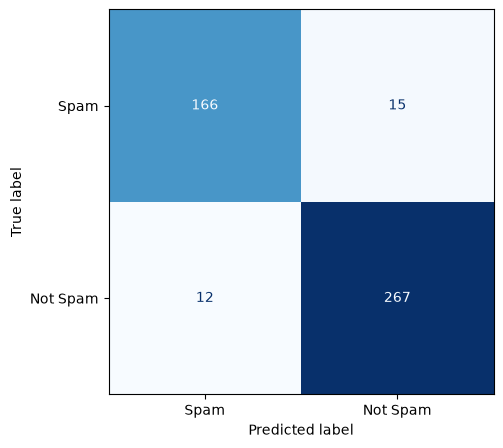

In [509]:
# Put the positive class (Default = 1) first
cm = confusion_matrix(
    y_validation,
    y_pred_validation,
    labels=[1, 0]
)

tp, fn, fp, tn = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Spam", "Not Spam"]
)

disp.plot(
    cmap="Blues",
    colorbar=False,
    values_format="d",
    ax=ax
)

In [510]:
# Your answer here, NOT in the next cell

a2a = accuracy_score(y_validation, y_pred_validation)      # Replace with an expression that returns the validation accuracy

In [511]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a2a = {a2a:.4f}')

a2a = 0.9413


In [512]:
# Your answer here, NOT in the next cell

a2b = tp/(tp+fn)      # Replace with an expression that returns the validation TPR

In [513]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a2b = {a2b:.4f}')

a2b = 0.9171


In [514]:
# Your answer here, NOT in the next cell

a2c = fp/(fp + tn)      # Replace with an expression that returns the validation FPR

In [515]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a2c = {a2c:.4f}')

a2c = 0.0430


## Problem 3: ROC Curve and AUC

In Problem 2, you evaluated the classifier at a single decision threshold of **0.50**.

A **Receiver Operating Characteristic (ROC) curve** shows how the classifier behaves across many possible decision thresholds. Each point on the ROC curve corresponds to a particular combination of:

- **True Positive Rate (TPR)**
- **False Positive Rate (FPR)**

The **Area Under the ROC Curve (AUC)** summarizes how well the classifier separates the two classes across all possible thresholds.

Using the predicted validation probabilities `y_prob_validation` from Problem 2:

1. Compute the ROC curve using `roc_curve()`.
2. Plot TPR against FPR.
3. Include the diagonal line representing random guessing.
4. Mark the operating point corresponding to the default threshold of **0.50**.
5. Compute the validation ROC AUC using `roc_auc_score()`.

Assign:

- `a3a` = the FPR values returned by `roc_curve()`
- `a3b` = the TPR values returned by `roc_curve()`
- `a3c` = validation ROC AUC

In [516]:
# Your code here, as more cells as needed
fpr_, tpr_, thresholds_ = roc_curve(y_validation, y_prob_validation, pos_label=1)

In [517]:
# Your answer here, NOT in the next cell

a3a = fpr_      # Replace with the FPR values returned by `roc_curve()`

In [518]:
idx = np.where(thresholds_ >= 0.5)[0][-1]  # smallest threshold that's still >= 0.5
tpr_[idx], fpr_[idx]

(np.float64(0.9171270718232044), np.float64(0.043010752688172046))

In [519]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a3a = {a3a}')

a3a = [0.         0.         0.         0.00716846 0.00716846 0.01075269
 0.01075269 0.01433692 0.01433692 0.01792115 0.01792115 0.02150538
 0.02150538 0.02150538 0.02508961 0.02508961 0.02867384 0.02867384
 0.03225806 0.03225806 0.03584229 0.03584229 0.03942652 0.03942652
 0.04301075 0.04301075 0.04659498 0.04659498 0.05376344 0.05376344
 0.0609319  0.0609319  0.07168459 0.07168459 0.08243728 0.08243728
 0.08960573 0.09318996 0.09318996 0.10752688 0.10752688 0.12544803
 0.12544803 0.12903226 0.12903226 0.24731183 0.24731183 0.34050179
 0.34050179 0.5125448  0.5125448  0.59856631 0.59856631 0.93189964
 0.95698925 0.97491039 0.98207885 1.        ]


In [520]:
# Your answer here, NOT in the next cell

a3b = tpr_      # Replace with the TPR values returned by `roc_curve()`

In [521]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a3b = {a3b}')

a3b = [0.         0.00552486 0.01657459 0.01657459 0.1160221  0.1160221
 0.13812155 0.13812155 0.54143646 0.54143646 0.60220994 0.60220994
 0.61325967 0.69060773 0.69060773 0.71270718 0.71270718 0.72375691
 0.72375691 0.74033149 0.74033149 0.83977901 0.83977901 0.86740331
 0.86740331 0.91712707 0.91712707 0.92265193 0.92265193 0.9281768
 0.9281768  0.93922652 0.93922652 0.95027624 0.95027624 0.9558011
 0.9558011  0.9558011  0.96132597 0.96132597 0.96685083 0.96685083
 0.97237569 0.97237569 0.97790055 0.97790055 0.98342541 0.98342541
 0.98895028 0.98895028 0.99447514 0.99447514 1.         1.
 1.         1.         1.         1.        ]


In [522]:
# Your answer here, NOT in the next cell

a3c = roc_auc_score(y_validation, y_pred_validation)      # Replace with the validation ROC AUC

In [523]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a3c = {a3c:.4f}')

a3c = 0.9371


## Problem 4: Select a Decision Threshold

The default threshold of **0.50** is not always the best choice for a classification problem.

For this spam-filtering application, suppose the provider wants to identify at least **95% of actual spam messages**.

Use the **validation set** to select a decision threshold using the following rule:

> Require a **True Positive Rate (TPR) of at least 0.95**.  
> Choose the **highest decision threshold** that satisfies this requirement.

Evaluate thresholds from **0.05 through 0.95 in increments of 0.01**.

For each threshold:

1. Convert `y_prob_validation` into class predictions.
2. Compute the confusion matrix.
3. Compute:
   - Accuracy
   - TPR
   - FPR
4. Store the results in a DataFrame called `threshold_results`.
5. Plot **TPR and FPR versus decision threshold**.
6. Select the threshold using the rule above.

Assign:

- `a4a` = selected threshold
- `a4b` = validation TPR at the selected threshold
- `a4c` = validation FPR at the selected threshold

In [524]:
# Your code here, as more cells as needed
thereshold_results_list = []
thresholds_to_evaluate = np.arange(.05, .95, .01)
for threshold in thresholds_to_evaluate: 
    class_predictions = np.where(y_prob_validation >= threshold, 1, 0)
    cm_threhold = confusion_matrix(y_validation, class_predictions, labels=[1,0])
    tp_t, fn_t, fp_t, tn_t = cm_threhold.ravel()
    accuracy_threhold = accuracy_score(y_validation, class_predictions)
    tpr_t = tp_t/(tp_t + fn_t)
    fpr_t = fp_t/(fp_t + tn_t)
    thereshold_results_list.append({"Threshold":threshold, "Accuracy":accuracy_threhold, "TPR":tpr_t, "FPR":fpr_t})
thereshold_results = pd.DataFrame(thereshold_results_list)

Text(0.5, 1.0, 'TPR and FDR plotted with Threshold')

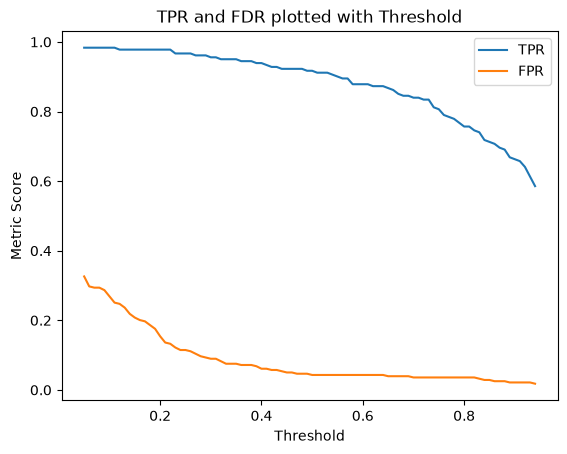

In [525]:
plt.plot(thereshold_results.Threshold, thereshold_results.TPR, label = 'TPR')
plt.plot(thereshold_results.Threshold, thereshold_results.FPR, label = 'FPR')
plt.xlabel('Threshold')
plt.ylabel("Metric Score")
plt.legend()
plt.title("TPR and FDR plotted with Threshold")

In [526]:
required_tpr_over_95 = thereshold_results[thereshold_results.TPR>=.95]
max_index = required_tpr_over_95.Threshold.idxmax()
row_max = required_tpr_over_95.iloc[max_index]
row_max

Threshold    0.350000
Accuracy     0.934783
TPR          0.950276
FPR          0.075269
Name: 30, dtype: float64

In [527]:

# Your answer here, NOT in the next cell
a4a = row_max.Threshold      # Replace with an expression that returns the selected threshold

In [528]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a4a = {a4a:.2f}')

a4a = 0.35


In [529]:
# Your answer here, NOT in the next cell

a4b = row_max.TPR      # Replace with an expression that returns the validation TPR at the selected threshold

In [530]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a4b = {a4b:.4f}')

a4b = 0.9503


In [531]:
# Your answer here, NOT in the next cell

a4c = row_max.FPR      # Replace with an expression that returns the validation FPR at the selected threshold

In [532]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a4c = {a4c:.4f}')

a4c = 0.0753


## Problem 5: Refit the Final Model and Evaluate on the Test Set

In Problem 4, you selected a decision threshold using only the **validation set**.

You will now evaluate the final model on the untouched **test set**.

Follow this workflow:

1. Create a new pipeline containing:
   - `StandardScaler()`
   - `LogisticRegression(max_iter=1000)`
2. Fit the pipeline using the complete **development set**:
   - `X_development`
   - `y_development`
3. Use `predict_proba()` to obtain predicted probabilities for the test set.
4. Apply the **same decision threshold selected in Problem 4**.
   - Do **not** choose a new threshold using the test set.
5. Compute:
   - Accuracy
   - TPR
   - FPR
   - ROC AUC
6. Display the final test confusion matrix.

Assign:

- `a5a` = test ROC AUC
- `a5b` = test TPR
- `a5c` = test FPR

Text(0.5, 1.0, 'Final confusion matrix with test data')

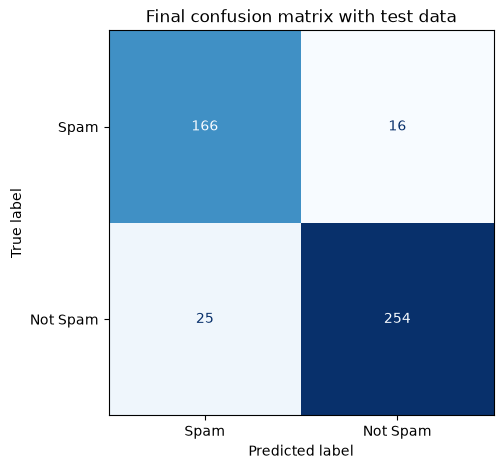

In [533]:
# Your code here, as more cells as needed
final_model = make_pipeline(
    StandardScaler(), 
    LogisticRegression(max_iter=1000)
)
final_model.fit(X_development, y_development)

test_predicted_probs = final_model.predict_proba(X_test)[:,1]
y_test_predictions = np.where(test_predicted_probs>= a4a, 1, 0)

accuracy_test = accuracy_score(y_test, y_test_predictions)
cm_test_final = confusion_matrix(y_test, y_test_predictions, labels= [1,0])
tp_final, fn_final, fp_final, tn_final = cm_test_final.ravel()
test_TPR = tp_final/(tp_final + fn_final)
test_FPR = fp_final/(fp_final + tn_final)
roc_auc_test_score = roc_auc_score(y_test, y_test_predictions)

fig, ax = plt.subplots(figsize=(5, 5))

display_final = ConfusionMatrixDisplay(
    confusion_matrix=cm_test_final,
    display_labels=["Spam", "Not Spam"]
)

display_final.plot(
    cmap="Blues",
    colorbar=False,
    values_format="d",
    ax=ax
)
plt.title('Final confusion matrix with test data')

In [534]:
# Your answer here, NOT in the next cell

a5a = roc_auc_test_score      # Replace with an expression that returns the test ROC AUC

In [535]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a5a = {a5a:.4f}')

a5a = 0.9112


In [536]:
# Your answer here, NOT in the next cell

a5b = test_TPR      # Replace with an expression that returns the test TPR

In [537]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a5b = {a5b:.4f}')

a5b = 0.9121


In [538]:
# Your answer here, NOT in the next cell

a5c = test_FPR      # Replace with an expression that returns the test FPR

In [539]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a5c = {a5c:.4f}')

a5c = 0.0896


## Problem 6: Multiple Choice

For each question, assign the number of the best answer to the corresponding variable.

Each question is worth **2 points**.

### Part A Graded Answer: Logistic Regression Output

A logistic regression model first computes the linear value

$$
z = \beta_0 + \beta_1x_1 + \cdots + \beta_mx_m.
$$

Why is the sigmoid function then applied to $z$?

1. To make the relationship between the predictors and $z$ linear
2. To transform $z$ into a value between 0 and 1 that can be interpreted as a probability
3. To choose the decision threshold that maximizes accuracy
4. To standardize the predictor variables

In [540]:
# Your answer here, NOT in the next cell

a6a = 2      # Replace with the number of the best answer

In [541]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a6a = {a6a}')

a6a = 2


### Part B Graded Answer: Cross-Entropy Loss

Suppose an email is actually spam, so $y=1$.

Which predicted probability for spam would produce the **largest cross-entropy loss**?

1. 0.99
2. 0.80
3. 0.50
4. 0.01

In [542]:
# Your answer here, NOT in the next cell

a6b = 4      # Replace with the number of the best answer

In [543]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a6b = {a6b}')

a6b = 4


### Part C Graded Answer: Decision Thresholds

Suppose the decision threshold for classifying an email as spam is lowered from 0.50 to 0.30.

What should generally happen?

1. Both TPR and FPR decrease
2. TPR increases and FPR decreases
3. TPR decreases and FPR increases
4. Both TPR and FPR increase

In [544]:
# Your answer here, NOT in the next cell

a6c = 4      # Replace with the number of the best answer

In [545]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a6c = {a6c}')

a6c = 4


### Part D Graded Answer: ROC AUC

Suppose you change the decision threshold used by a trained logistic regression model from 0.50 to 0.35.

Which statement is correct?

1. The ROC AUC must increase because TPR increases
2. The ROC AUC must decrease because FPR increases
3. The operating point on the ROC curve changes, but the ROC AUC does not change
4. Both the ROC curve and the ROC AUC must be recomputed from the new class predictions

In [546]:
# Your answer here, NOT in the next cell

a6d = 3      # Replace with the number of the best answer

In [547]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a6d = {a6d}')

a6d = 3


### Part E Graded Answer: Validation and Test Performance

In Problem 4, a decision threshold was selected because it achieved a validation TPR of at least 0.95.

After the final model was refit on the complete development set, its TPR on the untouched test set was lower than 0.95.

What is the best interpretation?

1. The threshold-selection procedure was incorrect because the test TPR must also be at least 0.95
2. The model should now be retuned using the test set until the test TPR reaches 0.95
3. The difference is expected because validation and test performance are estimates based on different samples
4. The lower test TPR proves that logistic regression is overfitting

In [548]:
# Your answer here, NOT in the next cell

a6e = 3      # Replace with the number of the best answer

In [549]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a6e = {a6e}')

a6e = 3


## Problem 7: Discussion

Throughout this homework, you trained a logistic regression model to identify spam and then used the **validation set** to select a decision threshold that achieved a TPR of at least 0.95 by choosing the highest threshold that satisfied this requirement. 

In one paragraph of approximately **5–7 sentences**, explain:

- how and why the selected threshold differed from the default threshold of 0.50, including the resulting tradeoff between TPR and FPR;
- why the threshold was selected using the validation set rather than the test set, and why the final test TPR did not have to remain at or above 0.95;
- what the final test results suggest about how well the modeling process generalized to previously unseen email.

Refer to at least **two specific numerical results** from your notebook.

In [550]:
# Your answer here, NOT in the next cell

a7 = """
We select a threshold that differed from the .50 by first using the training data to fit a model and then using that fitted model and pipeline 
on the validation data to get probability predictions. With these validation results we then applied the business requirement that we need to 
detect 95 percent of actual spam messages, meaning a .95 or greater TPR and found that .35 was the actual maximum threshold where this requirement 
was satisifed in the valdiation reults and it resulted in an FPR of 0.075. The threshold was selected using the valdiation set not the test set 
because you never want your model to learn anything from the test set because if we used the test set to inform the model then when we test 
we are not testing how the model generalizes, instead we are just memorizing the test data. The TPR did not have to remain above .95 because 
it is expected that there will be variability between the development and test data and also we chose a threhold right at the boundary of the .95 
requirement because we wanted to maximize threshold given the requirement. The final test results have slighlty lower TPR and slightly higher FPR than the 
validation run, so the performance is worse than the validation, but that is expected because we optimized the parameters to using all the development 
data. The overall performance is still good however with the ROC AUC above .90 which suggests very good performance.  
"""

In [551]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print("a7 =")
print(a7)

a7 =

We select a threshold that differed from the .50 by first using the training data to fit a model and then using that fitted model and pipeline 
on the validation data to get probability predictions. With these validation results we then applied the business requirement that we need to 
detect 95 percent of actual spam messages, meaning a .95 or greater TPR and found that .35 was the actual maximum threshold where this requirement 
was satisifed in the valdiation reults and it resulted in an FPR of 0.075. The threshold was selected using the valdiation set not the test set 
because you never want your model to learn anything from the test set because if we used the test set to inform the model then when we test 
we are not testing how the model generalizes, instead we are just memorizing the test data. The TPR did not have to remain above .95 because 
it is expected that there will be variability between the development and test data and also we chose a threhold right at the bound